In [10]:
import pandas as pd


df = pd.read_excel("Online Retail.xlsx")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Null values in each column

In [11]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Drop rows with missing CustomerID

In [14]:
df = df.dropna(subset=['CustomerID'])
# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

Duplicate rows

In [ ]:
duplicate_count = df.duplicated().sum()
print(f" Duplicate Rows : {duplicate_count:,}")
# drop duplicates
df = df.drop_duplicates()

 Duplicate Rows : 0


cancelled orders or negative quantity

In [35]:
cancelled_count = (df['Quantity'] < 0).sum()

print(f" Cancelled Orders or negative quantities: {cancelled_count:,}")

 Cancelled Orders or negative quantities: 0


Save cancelled orders separately, then remove

In [21]:

cancelled_orders = df[df['Quantity'] < 0]  # Save for later if needed

df = df[df['Quantity'] > 0]

In [ ]:
# CHECK: Zero quantities
zero_qty = (df['Quantity'] == 0).sum()
print(f"🔍 CHECK: Zero Quantities")
print(f"   Found: {zero_qty:,}")

🔍 CHECK: Zero Quantities
   Found: 0


In [33]:
# Invalid UnitPrice (zero or negative)
invalid_price = (df['UnitPrice'] <= 0).sum()
print(f"   Found: {invalid_price:,}")

   Found: 0


In [32]:
#cRemove rows with invalid prices
df = df[df['UnitPrice'] > 0]
print(f"   Remaining rows: {len(df):,}")

   Remaining rows: 392,692


In [ ]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [31]:
# After all cleaning is done
df = df.reset_index(drop=True)

EXPLORATORY DATA ANALYSIS (EDA)

In [38]:
import matplotlib.pyplot as plt



In [40]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

In [41]:
# First: Create Month column and monthly_revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

# Check it worked
print(monthly_revenue.head())

Month
2010-12    570422.730
2011-01    568101.310
2011-02    446084.920
2011-03    594081.760
2011-04    468374.331
Freq: M, Name: TotalPrice, dtype: float64


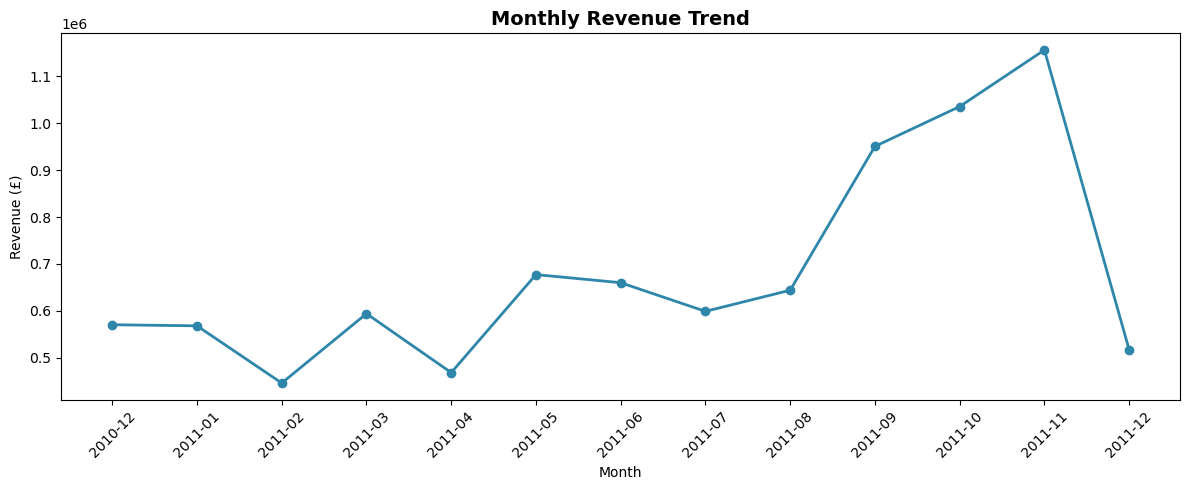

<Figure size 700x500 with 0 Axes>

In [46]:
# Plot Monthly Revenue Trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
         marker='o', linewidth=2, color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figure(figsize=(7, 5))
plt.show()

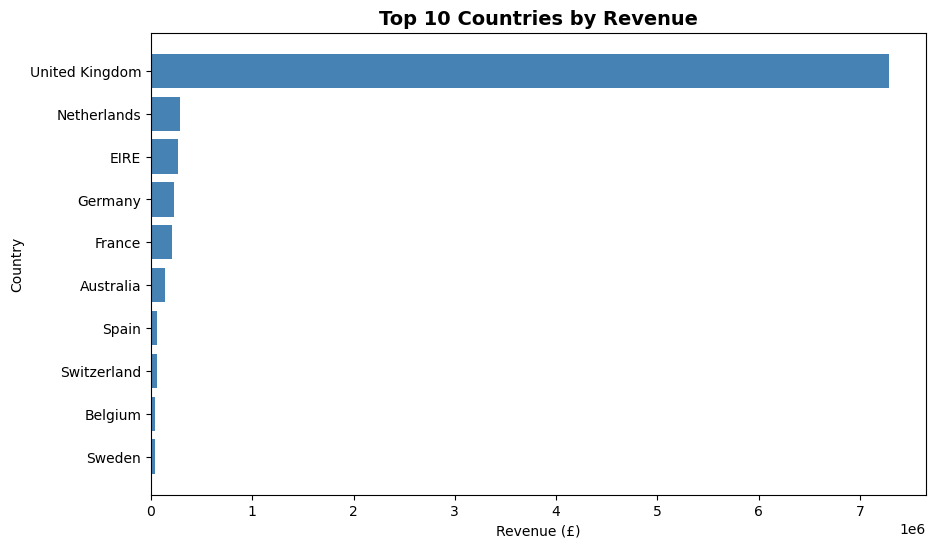

<Figure size 700x500 with 0 Axes>

In [56]:
# Prepare data
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
top_10_countries = country_revenue.head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_countries.index, top_10_countries.values, color='steelblue')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.figure(figsize=(7, 5))
plt.tight_layout()
plt.show()

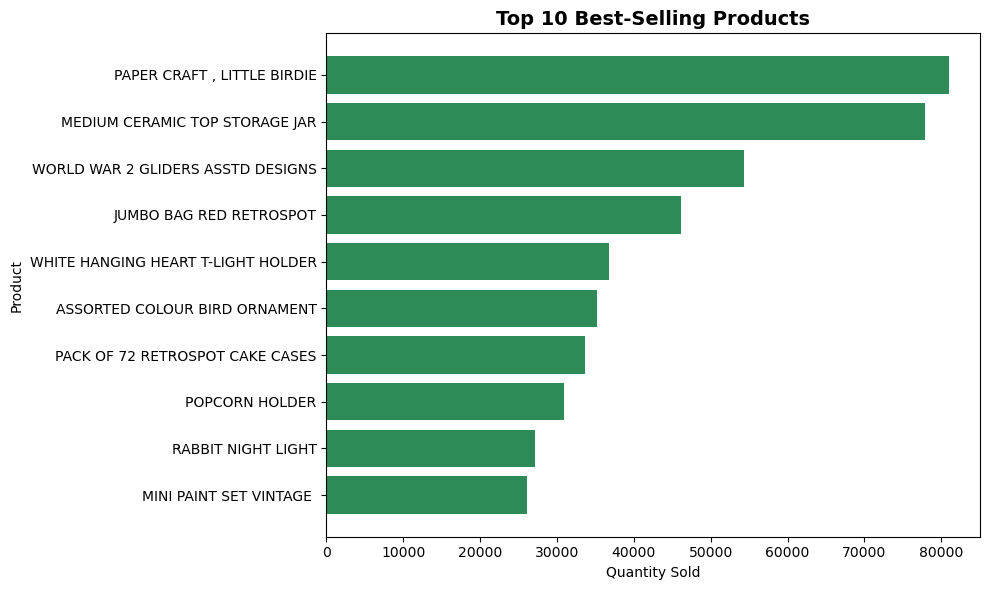

In [58]:
# Prepare data
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_10_products = top_products.head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_10_products.index, top_10_products.values, color='seagreen')
plt.title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Recency, Frequency, and Monetary value

In [ ]:
import datetime as dt

last_transaction = df['InvoiceDate'].max()
snapshot_date = last_transaction + dt.timedelta(days=1)

print(f" Data ranges: {df['InvoiceDate'].min().date()} to {last_transaction.date()}")
print(f" Analysis snapshot date: {snapshot_date.date()}")


📅 Data ranges: 2010-12-01 to 2011-12-09
📅 Analysis snapshot date: 2011-12-10


In [67]:
# Calculate Recency, Frequency, and Monetary for EACH customer

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: days since last purchase
    'InvoiceNo': 'nunique',                                    # Frequency: number of orders
    'TotalPrice': 'sum'                                        # Monetary: total spent
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(f"\nTotal customers analyzed: {len(rfm):,}")
rfm.head(10)


Total customers analyzed: 4,338


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,2506.04
12353,204,1,89.00
12354,232,1,1079.40
12355,214,1,459.40


In [71]:
print(f"\n RECENCY (days since last purchase):")
print(f"   Min:  {rfm['Recency'].min()} days")
print(f"   Max:  {rfm['Recency'].max()} days")
print(f"   Avg:  {rfm['Recency'].mean():.0f} days")

print(f"\n FREQUENCY (number of orders):")
print(f"   Min:  {rfm['Frequency'].min()} order")
print(f"   Max:  {rfm['Frequency'].max()} orders")
print(f"   Avg:  {rfm['Frequency'].mean():.1f} orders")

print(f"\n MONETARY (total spent):")
print(f"   Min:  ${rfm['Monetary'].min():.2f}")
print(f"   Max:  ${rfm['Monetary'].max():.2f}")
print(f"   Avg:  ${rfm['Monetary'].mean():.2f}")


 RECENCY (days since last purchase):
   Min:  1 days
   Max:  374 days
   Avg:  93 days

 FREQUENCY (number of orders):
   Min:  1 order
   Max:  209 orders
   Avg:  4.3 orders

 MONETARY (total spent):
   Min:  $3.75
   Max:  $280206.02
   Avg:  $2048.69


In [76]:
# Create R, F, M scores (4 = best, 1 = worst)

# Recency: Lower is better → 4 for most recent
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

# Frequency: Higher is better → 4 for most frequent
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Monetary: Higher is better → 4 for highest spenders
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine scores into single RFM score (e.g., "444" = best customer)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


print("\n Each customer now has R, F, M scores (1-4)")
print(" Combined RFM Score (e.g., 444 = Best, 111 = Worst)")
rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10)


 Each customer now has R, F, M scores (1-4)
 Combined RFM Score (e.g., 444 = Best, 111 = Worst)


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112
12352,36,8,2506.04,3,4,4,344
12353,204,1,89.00,1,1,1,111
12354,232,1,1079.40,1,1,3,113
12355,214,1,459.40,1,1,2,112


In [80]:
# Define customer segments based on RFM Score

def segment_customer(row):
    if row['RFM_Score'] in ['444', '443', '434', '344']:
        return 'Champions'
    elif row['RFM_Score'] in ['442', '441', '432', '431', '342', '341', '332']:
        return 'Loyal'
    elif row['RFM_Score'] in ['433', '424', '423', '414', '413', '334', '324', '314']:
        return 'Potential Loyalists'
    elif row['RFM_Score'] in ['333', '323', '322', '313', '312', '233', '223', '213']:
        return 'Needs Attention'
    elif row['RFM_Score'] in ['422', '421', '412', '411', '311']:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("\nEach customer now has a business segment")
rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']].head(10)


Each customer now has a business segment


,Recency,Frequency,Monetary,RFM_Score,Segment
CustomerID,,,,,
12346,326,1,77183.60,114,Lost
12347,2,7,4310.00,444,Champions
12348,75,4,1797.24,234,Lost
12349,19,1,1757.55,314,Potential Loyalists
12350,310,1,334.40,112,Lost
12352,36,8,2506.04,344,Champions
12353,204,1,89.00,111,Lost
12354,232,1,1079.40,113,Lost
12355,214,1,459.40,112,Lost


In [ ]:
# Count customers in each segment
segment_counts = rfm['Segment'].value_counts()
 
for segment, count in segment_counts.items():
    pct = (count / len(rfm)) * 100
    print(f"{segment:20s}: {count:5,} customers ({pct:.1f}%)")

Lost                : 2,051 customers (47.3%)
Champions           :   876 customers (20.2%)
Needs Attention     :   674 customers (15.5%)
At Risk             :   277 customers (6.4%)
Potential Loyalists :   270 customers (6.2%)
Loyal               :   190 customers (4.4%)


In [90]:
# Update action map WITHOUT emojis
action_map = {
    'Champions': 'Reward with VIP access & early product previews',
    'Loyal': 'Cross-sell & upsell premium products',
    'Potential Loyalists': 'Offer loyalty program or membership',
    'Needs Attention': 'Send limited-time discount offers',
    'At Risk': 'Send personalized re-engagement emails',
    'Lost': 'Offer deep discount or We Miss You campaign'
}

# Apply to RFM table
rfm['Recommended_Action'] = rfm['Segment'].map(action_map)

print("✅ Actions updated (emojis removed)")
rfm[['Segment', 'Recommended_Action']].head()

✅ Actions updated (emojis removed)


,Segment,Recommended_Action
CustomerID,,
12346,Lost,Offer deep discount or We Miss You campaign
12347,Champions,Reward with VIP access & early product previews
12348,Lost,Offer deep discount or We Miss You campaign
12349,Potential Loyalists,Offer loyalty program or membership
12350,Lost,Offer deep discount or We Miss You campaign


In [91]:
# Summary of actions
action_summary = rfm['Recommended_Action'].value_counts()


for action, count in action_summary.items():
    print(f"{action:50s}: {count:5,} customers")

Offer deep discount or We Miss You campaign       : 2,051 customers
Reward with VIP access & early product previews   :   876 customers
Send limited-time discount offers                 :   674 customers
Send personalized re-engagement emails            :   277 customers
Offer loyalty program or membership               :   270 customers
Cross-sell & upsell premium products              :   190 customers


In [92]:
# Re-save both files
df.to_csv('cleaned_transactions.csv', index=False)
rfm.to_csv('customer_segments.csv')

print("✅ Files re-exported successfully!")
print("1. cleaned_transactions.csv")
print("2. customer_segments.csv (with clean actions - no emojis)")

✅ Files re-exported successfully!
1. cleaned_transactions.csv
2. customer_segments.csv (with clean actions - no emojis)
